In [29]:
import matplotlib.pyplot as plt
import json
import os
BASE_DIR = '/root/workspace/vllm/examples/results/'
SOLO_DIR = BASE_DIR + '0_solorun_llm_1gpu/'

In [30]:
# 遍历SOLO_DIR下的所有文件，读取json文件，提取数据
def get_data(model_name):
    results = []
    for file in os.listdir(SOLO_DIR):
        if file.endswith('.json'):
            if model_name in file:
                with open(SOLO_DIR + file, 'r') as f:
                    data = json.load(f)
                    # 读取关键词：num_prompts， request_rate， p99_ttft_ms，mean_ttft_ms， p99_tpot_ms， mean_tpot_ms
                    # print(data['num_prompts'], data['request_rate'], data['p99_ttft_ms'], data['mean_ttft_ms'], data['p99_tpot_ms'], data['mean_tpot_ms'])
                    result = [data['num_prompts'], data['request_rate'], data['p99_ttft_ms'], data['mean_ttft_ms'], data['p99_tpot_ms'], data['mean_tpot_ms']]
                    results.append(result)
    return results

[[50, 1.0, 859.7337400168178, 124.34994466602802, 24.14098574472549, 17.870369470983487], [50, 2.0, 590.3426851890976, 79.02704701758921, 25.745016324303297, 20.65982086449095], [50, 5.0, 1031.9669701741077, 123.61492379568517, 31.052116014687222, 23.699176659488035], [50, 10.0, 1481.2488309363832, 273.0659469217062, 187.4792119172133, 34.91090316857793]]


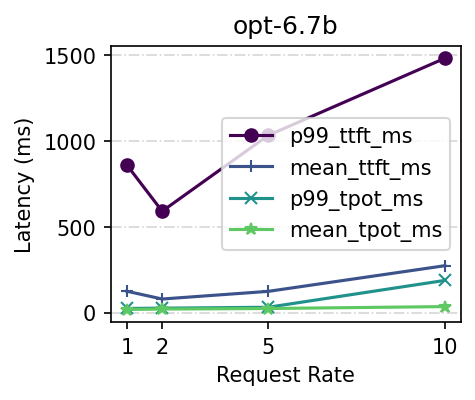

[[100, 1.0, 757.0917123090487, 83.0377353890799, 23.389098587619305, 18.205203286320383], [100, 2.0, 803.8018018170267, 99.459995822981, 26.976009006242684, 22.4229410068812], [100, 5.0, 1124.2963983700622, 95.89607140282169, 39.69501126143369, 29.74190797472722], [100, 10.0, 1278.6204468901274, 173.62065222812817, 179.0511921776594, 39.91107235267792]]


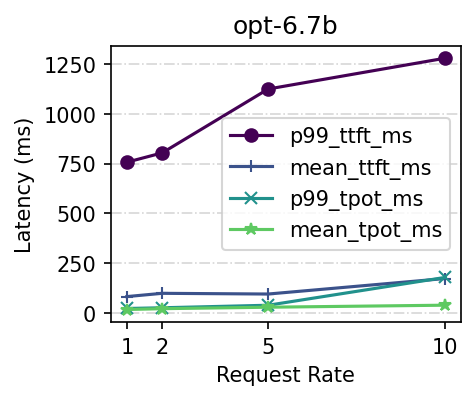

[[150, 1.0, 894.516570442352, 77.94113331474364, 26.583921726006427, 18.276116443611627], [150, 2.0, 968.1880411435817, 84.2535029196491, 28.072295822042328, 21.691309778874018], [150, 5.0, 1129.57014979096, 105.24988831331332, 52.499802012462276, 31.796685749951344], [150, 10.0, 1261.064254944212, 159.65382612620792, 81.07272242228062, 47.83212393080108]]


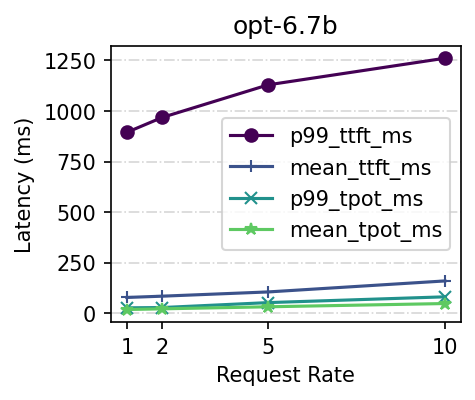

[[200, 1.0, 772.743726181797, 66.02042333455756, 23.216216466722212, 18.28672301229036], [200, 2.0, 609.6888946625398, 73.17493618349545, 32.007564721664856, 22.554214242892403], [200, 5.0, 1033.189706692936, 86.4764215471223, 47.86442344401701, 31.873072695771853], [200, 10.0, 1405.5196688813155, 183.71727367630228, 125.4661118900404, 51.242351569924665]]


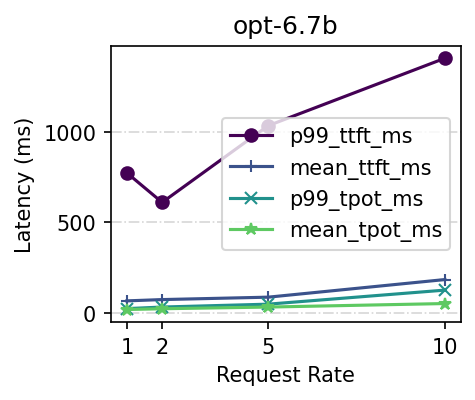

In [32]:
# 绘图
def plt_fig(request_rate, model_name):
    data = get_data(model_name)
    fig = plt.figure(figsize=(3, 2.5), dpi=150)
    ax = fig.add_subplot(1, 1, 1)
    ax.set_title(model_name)
    ax.set_xlabel('Request Rate')
    ax.set_ylabel('Latency (ms)')
    data = [x for x in data if x[0] == request_rate]
    data.sort(key=lambda x: x[1])
    print(data)
    label_name = ['p99_ttft_ms', 'mean_ttft_ms', 'p99_tpot_ms', 'mean_tpot_ms']
    markers = ['o', '+', 'x', '*']

    for i in range(4):
        ax.plot([x[1] for x in data], [x[i+2] for x in data], label=label_name[i], marker=markers[i], color=plt.cm.viridis(i/4))
    plt.xticks([x[1] for x in data])
    ax.legend()
    ax.grid(axis='y', alpha=0.5, linestyle='-.')
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.show()
model_name = 'opt-6.7b'
request_rates = [50, 100, 150, 200]
for request_rate in request_rates:
    plt_fig(request_rate, model_name)